# Cross-Asset Skew Strategy (yfinance Replication)

This notebook replicates the cross-asset skew strategy workflow using free Yahoo Finance data via `yfinance`.

Pipeline:
1. Load ETF universe data
2. Compute rolling skew signal
3. Build monthly cross-sectional long/short weights within asset class
4. Backtest daily portfolio returns
5. Volatility-normalize and aggregate a global factor
6. Run alpha/beta regressions and equity factor regression

In [1]:
import datetime as dt
import warnings

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm

warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.display.float_format = "{:.6f}".format

In [2]:
# Strategy parameters
LOOKBACK = 256
HISTORY_DAYS = 3650  # ~10 years
VOL_TARGET = 0.10

# Universe (inspired by experiments/cam_skewness_v1.ipynb)
universe = [
    ("Equity", ["SPY", "EWU", "EWJ", "INDA", "EWG", "EWL", "EWP", "EWQ",
                "VTI", "FXI", "EWZ", "EWY", "EWA", "EWC", "EWG",
                "EWH", "EWI", "EWN", "EWD", "EWT", "EZA", "EWW", "ENOR", "EDEN", "TUR"]),
    ("FI", ["AGG", "TLT", "LQD", "JNK", "MUB", "MBB", "IAGG", "IGOV", "EMB",
            "BND", "BNDX", "VCIT", "VCSH", "BSV", "SRLN"]),
    ("Commodities", ["GLD", "SLV", "GSG", "USO", "PPLT", "UNG", "DBA"]),
    ("Other", ["IYR", "REET", "USRT", "ICF", "VNQ"]),
    ("Ccy", ["UUP", "FXY", "FXE", "FXF", "FXB", "FXA", "FXC"]),
]

In [3]:
LOADER_VERSION = "yf_loader_v3_2026_03_14"


def clean_yf(raw: pd.DataFrame, ticker: str) -> pd.DataFrame:
    base_cols = ["Date", "Ticker", "close", "open", "NextOpen", "LogReturn"]

    if raw is None or raw.empty:
        return pd.DataFrame(columns=base_cols)

    df = raw.copy()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]

    df = df.reset_index()
    if "Date" not in df.columns and "Datetime" in df.columns:
        df = df.rename(columns={"Datetime": "Date"})

    if "Date" not in df.columns or "Open" not in df.columns:
        return pd.DataFrame(columns=base_cols)

    close_col = "Adj Close" if "Adj Close" in df.columns else ("Close" if "Close" in df.columns else None)
    if close_col is None:
        return pd.DataFrame(columns=base_cols)

    df["Date"] = pd.to_datetime(df["Date"]).dt.normalize()
    df["Ticker"] = ticker
    df["close"] = pd.to_numeric(df[close_col], errors="coerce")
    df["open"] = pd.to_numeric(df["Open"], errors="coerce")

    df = df.sort_values("Date").drop_duplicates(subset=["Date"], keep="last")
    df["NextOpen"] = df["open"].shift(-1)
    df["LogReturn"] = np.log(df["close"] / df["close"].shift(1))

    return df[base_cols].dropna(subset=["close", "open"])


def load_ticker_yf(ticker: str, start_date: pd.Timestamp, end_date: pd.Timestamp) -> pd.DataFrame:
    raw = yf.download(
        ticker,
        start=start_date.date(),
        end=end_date.date(),
        interval="1d",
        auto_adjust=False,
        progress=False,
        threads=False,
    )
    return clean_yf(raw, ticker)


def load_universe_yf(universe_spec):
    end_date = pd.Timestamp(dt.datetime.now().date()) + pd.Timedelta(days=1)
    start_date = end_date - pd.Timedelta(days=HISTORY_DAYS)

    frames = []
    failures = []

    for asset_class, tickers in universe_spec:
        for ticker in sorted(set(tickers)):
            try:
                df = load_ticker_yf(ticker, start_date, end_date)
                if df.empty:
                    failures.append((asset_class, ticker, "empty or missing required columns"))
                    continue
                df["AssetClass"] = asset_class
                frames.append(df)
            except Exception as exc:
                failures.append((asset_class, ticker, str(exc)))

    all_cols = ["Date", "Ticker", "close", "open", "NextOpen", "LogReturn", "AssetClass"]
    if frames:
        all_data = pd.concat(frames, ignore_index=True)
        all_data = all_data.sort_values(["Ticker", "Date"]).reset_index(drop=True)
    else:
        all_data = pd.DataFrame(columns=all_cols)

    if failures:
        print(f"Failed tickers: {len(failures)}")
        print(pd.DataFrame(failures, columns=["AssetClass", "Ticker", "Error"]).head(50))

    if all_data.empty:
        print("No data loaded. Check internet connection, yfinance version, or ticker availability.")

    return all_data



In [4]:
import inspect
print("No data loaded" in inspect.getsource(load_universe_yf))

True


In [5]:
print("Loader:", LOADER_VERSION)
all_data = load_universe_yf(universe)
print(all_data.shape)
print("Columns:", list(all_data.columns))
if all_data.empty:
    raise RuntimeError("No data loaded from yfinance. Check network, yfinance install, or ticker availability before proceeding.")
if "Ticker" not in all_data.columns:
    raise RuntimeError(f"Schema mismatch after load. Missing Ticker column. Got columns={list(all_data.columns)}")
all_data.head()

Loader: yf_loader_v3_2026_03_14
(145696, 7)
Columns: ['Date', 'Ticker', 'close', 'open', 'NextOpen', 'LogReturn', 'AssetClass']


,Date,Ticker,close,open,NextOpen,LogReturn,AssetClass
0,2016-03-17,AGG,83.521591,109.949997,110.190002,NaN,FI
1,2016-03-18,AGG,83.589828,110.190002,110.059998,0.000817,FI
2,2016-03-21,AGG,83.407745,110.059998,110.269997,-0.002181,FI
3,2016-03-22,AGG,83.354599,110.269997,109.959999,-0.000637,FI
4,2016-03-23,AGG,83.536751,109.959999,110.290001,0.002183,FI


In [6]:
def add_skew_features(df: pd.DataFrame, lookback: int = LOOKBACK) -> pd.DataFrame:
    required = {"Date", "Ticker", "LogReturn"}
    missing = required.difference(df.columns)
    if missing:
        raise KeyError(f"Input df missing required columns: {sorted(missing)}")

    if df.empty:
        out = df.copy()
        out["Avg"] = np.nan
        out["Dev"] = np.nan
        out["SkewDay"] = np.nan
        out["Skew"] = np.nan
        return out

    out = df.copy().sort_values(["Ticker", "Date"]).reset_index(drop=True)
    grp = out.groupby("Ticker", sort=False)["LogReturn"]

    out["Avg"] = grp.transform(lambda s: s.rolling(window=lookback, min_periods=lookback).mean())
    out["Dev"] = grp.transform(lambda s: s.rolling(window=lookback, min_periods=lookback).std())

    z = (out["LogReturn"] - out["Avg"]) / out["Dev"]
    out["SkewDay"] = z ** 3
    out["Skew"] = out.groupby("Ticker", sort=False)["SkewDay"].transform(
        lambda s: s.rolling(window=lookback, min_periods=lookback).mean()
    )

    out = out.dropna(subset=["Skew"]).reset_index(drop=True)
    return out


all_data = add_skew_features(all_data)
print(all_data.shape)
print("Columns:", list(all_data.columns))
all_data.head()

(116058, 11)
Columns: ['Date', 'Ticker', 'close', 'open', 'NextOpen', 'LogReturn', 'AssetClass', 'Avg', 'Dev', 'SkewDay', 'Skew']


,Date,Ticker,close,open,NextOpen,LogReturn,AssetClass,Avg,Dev,SkewDay,Skew
0,2018-03-28,AGG,85.040550,107.050003,106.949997,0.000561,FI,0.000039,0.001627,0.033121,0.052545
1,2018-03-29,AGG,85.287094,106.949997,106.900002,0.002895,FI,0.000049,0.001637,5.254915,0.073065
2,2018-04-02,AGG,85.201782,106.900002,106.820000,-0.001001,FI,0.000048,0.001637,-0.262904,0.072328
3,2018-04-03,AGG,85.106148,106.820000,106.900002,-0.001123,FI,0.000034,0.001632,-0.356521,0.064952
4,2018-04-04,AGG,85.138023,106.900002,106.709999,0.000374,FI,0.000045,0.001626,0.008328,0.070850


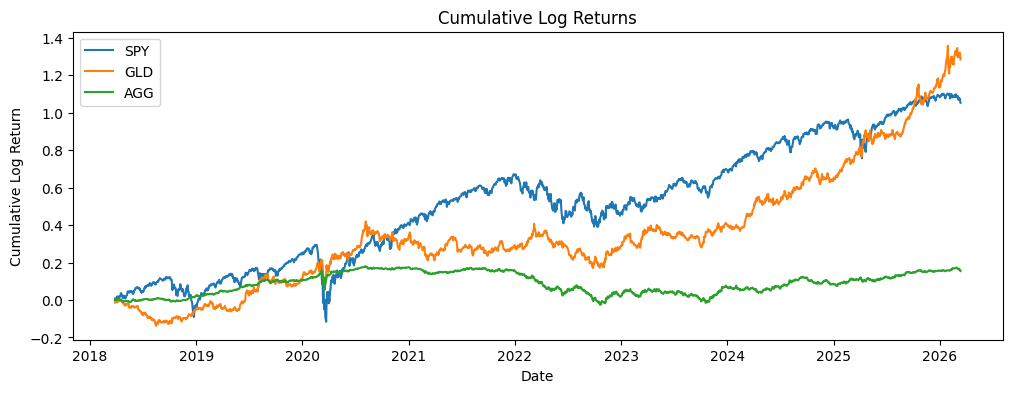

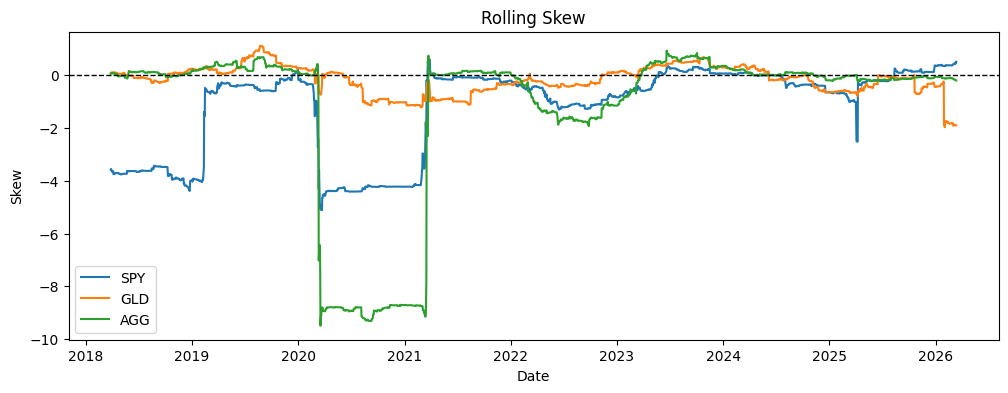

In [7]:
# Quick diagnostics: cumulative returns and skew for sample ETFs
if "Ticker" not in all_data.columns:
    raise RuntimeError(f"Expected Ticker column before diagnostics. Got columns={list(all_data.columns)}")

sample_tickers = ["SPY", "GLD", "AGG"]
sample = all_data[all_data["Ticker"].isin(sample_tickers)].copy()

plt.figure(figsize=(12, 4))
for t in sample_tickers:
    s = sample[sample["Ticker"] == t]
    if not s.empty:
        plt.plot(s["Date"], s["LogReturn"].cumsum(), label=t)
plt.title("Cumulative Log Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Log Return")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
for t in sample_tickers:
    s = sample[sample["Ticker"] == t]
    if not s.empty:
        plt.plot(s["Date"], s["Skew"], label=t)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Rolling Skew")
plt.xlabel("Date")
plt.ylabel("Skew")
plt.legend()
plt.show()

## Backtest Construction

- Rebalance monthly using end-of-month skew signal.
- Within each asset class, rank by skew (most negative skew gets positive weight).
- Normalize weights so longs sum to `+1` and shorts sum to `-1` per asset class.
- Apply weights from the next trading day onward until next rebalance.

In [8]:
bt = all_data.copy().sort_values(["Ticker", "Date"]).reset_index(drop=True)

bt["Month"] = bt["Date"].dt.to_period("M").dt.to_timestamp()
bt["NextDay"] = bt.groupby("Ticker")["Date"].shift(-1)

# Place final missing next-day beyond sample end.
bt["NextDay"] = bt["NextDay"].fillna(bt["Date"] + pd.offsets.BDay(1))

monthly_vals = (
    bt.groupby(["Month", "AssetClass", "Ticker"], as_index=False)
      .agg(Date=("Date", "last"), NextDate=("NextDay", "last"), EOMSkew=("Skew", "last"))
)

monthly_vals["SkewWeightRaw"] = monthly_vals.groupby(["Date", "AssetClass"])["EOMSkew"].transform(
    lambda s: s.rank(ascending=False, method="average") - ((len(s) + 1) / 2)
)

def normalize_raw_weights(s: pd.Series) -> pd.Series:
    denom = s.abs().sum() / 2
    if denom == 0 or pd.isna(denom):
        return pd.Series(np.zeros(len(s)), index=s.index)
    return s / denom

monthly_vals["SkewWeight"] = monthly_vals.groupby(["Date", "AssetClass"])["SkewWeightRaw"].transform(normalize_raw_weights)

monthly_vals.head()

,Month,AssetClass,Ticker,Date,NextDate,EOMSkew,SkewWeightRaw,SkewWeight
0,2018-03-01,Ccy,FXA,2018-03-29,2018-04-02,-0.092163,3.000000,0.500000
1,2018-03-01,Ccy,FXB,2018-03-29,2018-04-02,0.203700,-1.000000,-0.166667
2,2018-03-01,Ccy,FXC,2018-03-29,2018-04-02,0.309923,-2.000000,-0.333333
3,2018-03-01,Ccy,FXE,2018-03-29,2018-04-02,0.313896,-3.000000,-0.500000
4,2018-03-01,Ccy,FXF,2018-03-29,2018-04-02,0.121835,0.000000,0.000000


In [9]:
# Join monthly weights on their activation date (next trading day), then forward-fill within ticker
weightings = monthly_vals[["NextDate", "Ticker", "SkewWeight"]].rename(columns={"NextDate": "Date"})

all_data_weights = bt.merge(weightings, on=["Date", "Ticker"], how="left")
all_data_weights = all_data_weights.sort_values(["Ticker", "Date"]).reset_index(drop=True)
all_data_weights["SkewWeightFF"] = all_data_weights.groupby("Ticker")["SkewWeight"].ffill()

all_data_weights[["Date", "Ticker", "AssetClass", "LogReturn", "SkewWeight", "SkewWeightFF"]].head()

,Date,Ticker,AssetClass,LogReturn,SkewWeight,SkewWeightFF
0,2018-03-28,AGG,FI,0.000561,NaN,NaN
1,2018-03-29,AGG,FI,0.002895,NaN,NaN
2,2018-04-02,AGG,FI,-0.001001,-0.142857,-0.142857
3,2018-04-03,AGG,FI,-0.001123,NaN,-0.142857
4,2018-04-04,AGG,FI,0.000374,NaN,-0.142857


In [10]:
# Daily per-asset-class returns
all_data_weights["WeightedReturn"] = all_data_weights["SkewWeightFF"] * all_data_weights["LogReturn"]

asset_portfolios = (
    all_data_weights.groupby(["Date", "AssetClass"], as_index=False)
    .agg(
        PortfolioReturn=("WeightedReturn", "sum"),
        MktReturn=("LogReturn", "mean"),
    )
    .dropna()
)

asset_portfolios.head()

,Date,AssetClass,PortfolioReturn,MktReturn
0,2018-03-28,Ccy,0.000000,-0.004800
1,2018-03-28,Commodities,0.000000,-0.006120
2,2018-03-28,Equity,0.000000,-0.000075
3,2018-03-28,FI,0.000000,0.000153
4,2018-03-28,Other,0.000000,0.022488


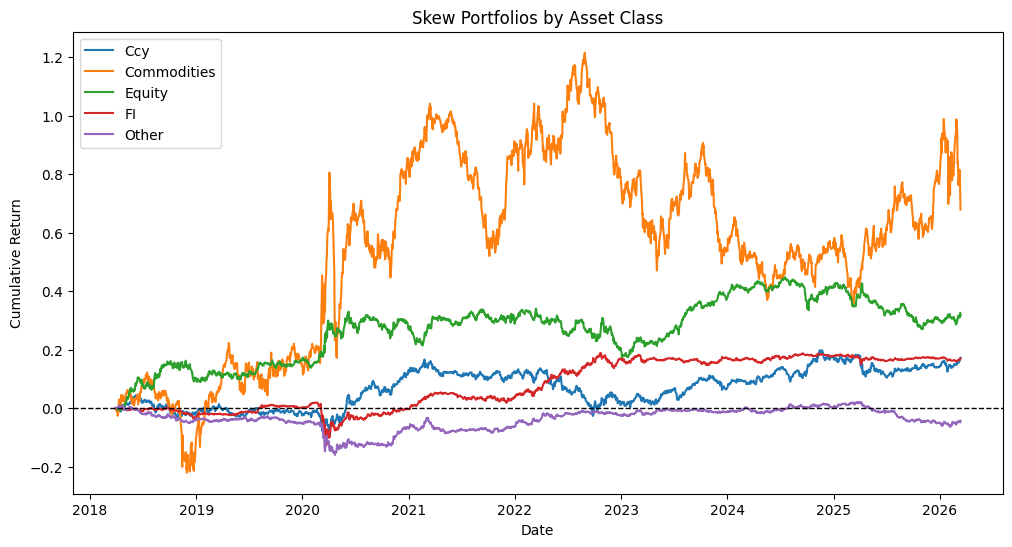

In [11]:
# Plot cumulative returns by asset class
plt.figure(figsize=(12, 6))
for ac in sorted(asset_portfolios["AssetClass"].unique()):
    ac_data = asset_portfolios[asset_portfolios["AssetClass"] == ac]
    plt.plot(ac_data["Date"], ac_data["PortfolioReturn"].cumsum(), label=ac)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Skew Portfolios by Asset Class")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()

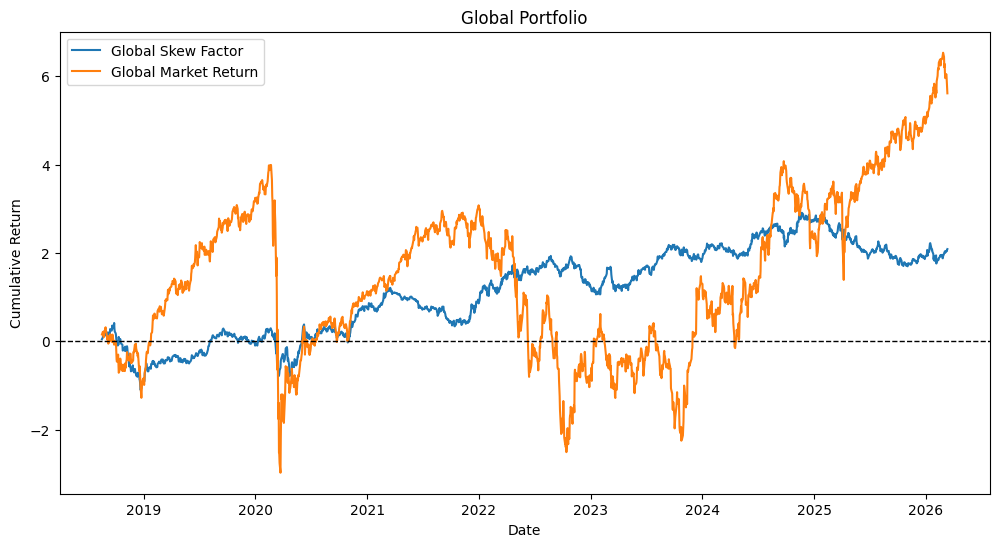

In [12]:
# Volatility normalization and global factor
asset_portfolios = asset_portfolios.sort_values(["AssetClass", "Date"]).reset_index(drop=True)
asset_portfolios["Vol"] = asset_portfolios.groupby("AssetClass")["PortfolioReturn"].transform(
    lambda s: s.rolling(window=LOOKBACK, min_periods=100).std()
)

asset_portfolios["NormReturn"] = VOL_TARGET * asset_portfolios["PortfolioReturn"] / asset_portfolios["Vol"]
asset_portfolios["NormMarketReturn"] = VOL_TARGET * asset_portfolios["MktReturn"] / asset_portfolios["Vol"]

gcf = (
    asset_portfolios.dropna(subset=["NormReturn", "NormMarketReturn"])
    .groupby("Date", as_index=False)
    .agg(Return=("NormReturn", "mean"), MktReturn=("NormMarketReturn", "mean"))
)

plt.figure(figsize=(12, 6))
plt.plot(gcf["Date"], gcf["Return"].cumsum(), label="Global Skew Factor")
plt.plot(gcf["Date"], gcf["MktReturn"].cumsum(), label="Global Market Return")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Global Portfolio")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()

In [13]:
# Alpha/Beta regression by asset class
rows = []
for ac in sorted(asset_portfolios["AssetClass"].unique()):
    ac_data = asset_portfolios[asset_portfolios["AssetClass"] == ac].dropna(subset=["PortfolioReturn", "MktReturn"])
    X = sm.add_constant(ac_data["MktReturn"])
    y = ac_data["PortfolioReturn"]
    model = sm.OLS(y, X).fit()
    rows.append({
        "Asset Class": ac,
        "alpha": model.params.get("const", np.nan),
        "alpha_p": model.pvalues.get("const", np.nan),
        "beta": model.params.get("MktReturn", np.nan),
        "beta_p": model.pvalues.get("MktReturn", np.nan),
        "R2": model.rsquared,
    })

results_table = pd.DataFrame(rows).sort_values("Asset Class").reset_index(drop=True)
results_table

,Asset Class,alpha,alpha_p,beta,beta_p,R2
0,Ccy,0.000087,0.448704,0.203284,0.000000,0.013041
1,Commodities,0.000327,0.526863,0.058643,0.178095,0.000907
2,Equity,0.000168,0.235449,-0.032288,0.006319,0.003724
3,FI,0.000086,0.235865,-0.021469,0.316449,0.000502
4,Other,-0.000024,0.717756,0.009861,0.042310,0.002061


## Deeper Equity Factor Regression

Regress Equity skew portfolio returns on Equity market return plus proxy factor ETFs:
- `MTUM` (momentum)
- `VTV` (value)
- `VUG` (growth)
- `VIG` (quality/dividend proxy)

In [14]:
factor_tickers = ["MTUM", "VTV", "VUG", "VIG"]
end_date = pd.Timestamp(dt.datetime.now().date()) + pd.Timedelta(days=1)
start_date = end_date - pd.Timedelta(days=HISTORY_DAYS)

factor_frames = []
for t in factor_tickers:
    f = load_ticker_yf(t, start_date, end_date)
    if not f.empty:
        factor_frames.append(f)

if not factor_frames:
    raise ValueError("Could not load factor ETFs from yfinance.")

equity_factors = pd.concat(factor_frames, ignore_index=True)
factor_wide = equity_factors.pivot(index="Date", columns="Ticker", values="LogReturn").reset_index()

equity = asset_portfolios[asset_portfolios["AssetClass"] == "Equity"].copy()
equity = equity.merge(factor_wide, on="Date", how="left")

reg_cols = ["MktReturn", "MTUM", "VTV", "VUG", "VIG"]
reg_df = equity.dropna(subset=["PortfolioReturn"] + reg_cols).copy()

X = sm.add_constant(reg_df[reg_cols])
y = reg_df["PortfolioReturn"]
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        PortfolioReturn   R-squared:                       0.116
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     52.43
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           3.14e-51
Time:                        20:46:25   Log-Likelihood:                 7409.7
No. Observations:                2001   AIC:                        -1.481e+04
Df Residuals:                    1995   BIC:                        -1.477e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       9.151e-05      0.000      0.684      0.4

In [15]:
# Compact coefficient table
coef_table = pd.DataFrame({
    "Coef": model.params,
    "StdErr": model.bse,
    "t": model.tvalues,
    "p": model.pvalues,
    "CI_L": model.conf_int()[0],
    "CI_U": model.conf_int()[1],
}).round(6)
coef_table

,Coef,StdErr,t,p,CI_L,CI_U
const,0.000092,0.000134,0.684356,0.493830,-0.000171,0.000354
MktReturn,-0.329039,0.023533,-13.981824,0.000000,-0.375192,-0.282887
MTUM,-0.077895,0.022660,-3.437541,0.000599,-0.122335,-0.033455
VTV,0.474240,0.049460,9.588301,0.000000,0.377241,0.571239
VUG,0.131554,0.026838,4.901754,0.000001,0.078920,0.184188
VIG,-0.180912,0.059527,-3.039148,0.002403,-0.297655,-0.064170


In [16]:
# Basic sanity checks
check = monthly_vals.groupby(["Date", "AssetClass"]).agg(
    long_sum=("SkewWeight", lambda s: s[s > 0].sum()),
    short_sum=("SkewWeight", lambda s: s[s < 0].sum()),
    net=("SkewWeight", "sum"),
).reset_index()

check.describe()

,Date,long_sum,short_sum,net
count,485,485.000000,485.000000,485.000000
mean,2022-03-30 19:17:56,1.000000,-1.000000,-0.000000
min,2018-03-29 00:00:00,1.000000,-1.000000,-0.000000
25%,2020-03-31 00:00:00,1.000000,-1.000000,0.000000
50%,2022-03-31 00:00:00,1.000000,-1.000000,0.000000
75%,2024-03-28 00:00:00,1.000000,-1.000000,0.000000
max,2026-03-13 00:00:00,1.000000,-1.000000,0.000000
std,NaN,0.000000,0.000000,0.000000
